# M1

In [ ]:
# =============================================================================
# EKSPERIMEN M1 — Prediksi Disposisi Pasien IGD (Admit vs Discharge)
# Big Data IGD | Institut Teknologi Sumatera
# =============================================================================
# Alur:
#   1. Load Data & Feature Selection
#   2. Preprocessing (imputasi, encoding, feature engineering)
#   3. Split Walk-Forward (70% train | 15% val | 15% test)
#   4. Medical Rule Engine (hierarki prioritas ESI)
#   5. Training: Logistic Regression | Decision Tree | Random Forest | XGBoost
#   6. Evaluasi & Visualisasi lengkap
# =============================================================================

import pandas as pd
import numpy as np
import warnings
import time
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, recall_score, f1_score,
    precision_score, accuracy_score,
    confusion_matrix, roc_curve
)
import xgboost as xgb

warnings.filterwarnings('ignore')

In [ ]:
# =============================================================================
# STEP 1: LOAD DATA & FEATURE SELECTION
# =============================================================================
print("=" * 60)
print("STEP 1: LOAD DATA")
print("=" * 60)

# Sesuaikan path dataset jika perlu
df = pd.read_csv('/content/5v_cleandf_relevant.csv')

FEATURES = [
    'age', 'gender', 'esi', 'arrivalmode', 'dep_name',
    'albumin_last', 'aniongap_last', 'bilirubintotal_last',
    'arrivalmonth', 'arrivalday', 'arrivalhour_bin', 'previousdispo'
]
TARGET = 'disposition'

df_sel = df[FEATURES + [TARGET]].copy()
print(f"Shape awal  : {df_sel.shape}")
print(f"Distribusi target:\n{df_sel[TARGET].value_counts()}\n")

STEP 1: LOAD DATA
Shape awal  : (560486, 13)
Distribusi target:
disposition
Discharge    393848
Admit        166638
Name: count, dtype: int64



In [ ]:
# =============================================================================
# STEP 2: PREPROCESSING
# =============================================================================
print("=" * 60)
print("STEP 2: PREPROCESSING")
print("=" * 60)

# 2a. Hapus baris tanpa ESI (tidak bisa dikelompokkan secara medis)
before = len(df_sel)
df_sel = df_sel.dropna(subset=['esi'])
print(f"Drop NaN ESI : {before:,} → {len(df_sel):,} baris")

# 2b. Imputasi numerik — median global
for col in ['age', 'albumin_last', 'aniongap_last', 'bilirubintotal_last']:
    df_sel[col] = df_sel[col].fillna(df_sel[col].median())

# 2c. Imputasi kategorikal — modus
df_sel['arrivalmode'] = df_sel['arrivalmode'].fillna('Walk-in')

print(f"Missing values tersisa: {df_sel[FEATURES].isnull().sum().sum()}")

# 2d. Encoding target: Admit = 1, Discharge = 0
df_sel['label'] = (df_sel[TARGET] == 'Admit').astype(int)
print(f"Label distribusi: {df_sel['label'].value_counts().to_dict()}")

STEP 2: PREPROCESSING
Drop NaN ESI : 560,486 → 558,029 baris
Missing values tersisa: 0
Label distribusi: {0: 392007, 1: 166022}


In [ ]:
# =============================================================================
# STEP 3: FEATURE ENGINEERING
# =============================================================================
print("\n" + "=" * 60)
print("STEP 3: FEATURE ENGINEERING")
print("=" * 60)

# Flag medis berbasis ESI (mendukung Rule Engine)
df_sel['is_critical']    = (df_sel['esi'] <= 2).astype(int)   # ESI 1-2 → kritis
df_sel['is_mild']        = (df_sel['esi'] >= 4).astype(int)   # ESI 4-5 → ringan
df_sel['prev_was_admit'] = (df_sel['previousdispo'] == 'Admit').astype(int)

# Kelompok usia
df_sel['age_group'] = pd.cut(
    df_sel['age'],
    bins=[0, 17, 40, 60, 150],
    labels=['anak', 'dewasa_muda', 'dewasa', 'lansia']
)

# Encoding semua kolom kategorikal
cat_cols = [
    'gender', 'arrivalmode', 'dep_name', 'arrivalmonth',
    'arrivalday', 'arrivalhour_bin', 'previousdispo', 'age_group'
]
for col in cat_cols:
    le = LabelEncoder()
    df_sel[col] = le.fit_transform(df_sel[col].astype(str))

FINAL_FEATURES = [
    'age', 'esi', 'is_critical', 'is_mild', 'prev_was_admit',
    'albumin_last', 'aniongap_last', 'bilirubintotal_last',
    'gender', 'arrivalmode', 'dep_name',
    'arrivalmonth', 'arrivalday', 'arrivalhour_bin',
    'previousdispo', 'age_group'
]

X = df_sel[FINAL_FEATURES].values
y = df_sel['label'].values
esi_vals = df_sel['esi'].values

print(f"Fitur final  : {len(FINAL_FEATURES)} fitur")
print(f"Shape X      : {X.shape}")


STEP 3: FEATURE ENGINEERING
Fitur final  : 16 fitur
Shape X      : (558029, 16)


In [ ]:
# =============================================================================
# STEP 4: SPLIT DATA — WALK-FORWARD (TIME-SERIES)
# =============================================================================
print("\n" + "=" * 60)
print("STEP 4: SPLIT DATA — Walk-Forward Validation")
print("=" * 60)

n       = len(X)
n_train = int(n * 0.70)
n_val   = int(n * 0.85)

X_train, y_train = X[:n_train],  y[:n_train]
X_val,   y_val   = X[n_train:n_val], y[n_train:n_val]
X_test,  y_test  = X[n_val:],    y[n_val:]
esi_test         = esi_vals[n_val:]

print(f"Train : {len(X_train):>7,}  |  Admit%: {y_train.mean()*100:.1f}%")
print(f"Val   : {len(X_val):>7,}  |  Admit%: {y_val.mean()*100:.1f}%")
print(f"Test  : {len(X_test):>7,}  |  Admit%: {y_test.mean()*100:.1f}%")


STEP 4: SPLIT DATA — Walk-Forward Validation
Train : 390,620  |  Admit%: 30.8%
Val   :  83,704  |  Admit%: 25.2%
Test  :  83,705  |  Admit%: 29.5%


In [ ]:
# =============================================================================
# STEP 5: MEDICAL RULE ENGINE
# =============================================================================
print("\n" + "=" * 60)
print("STEP 5: MEDICAL RULE ENGINE — Hierarki Prioritas ESI")
print("=" * 60)

def apply_rule_engine(esi_arr: np.ndarray, ml_proba: np.ndarray) -> np.ndarray:
    """
    Menggabungkan prediksi ML dengan aturan medis berbasis ESI.

    Hierarki:
    - ESI 1-2 → LOCK Admit (probabilitas ~100%, nyawa terancam)
    - ESI 3   → Gunakan skor ML, threshold 0.40 (lebih sensitif)
    - ESI 4-5 → Gunakan skor ML, threshold 0.60 (default Discharge)

    Parameters
    ----------
    esi_arr  : array ESI tiap pasien
    ml_proba : probabilitas Admit dari model ML

    Returns
    -------
    final_pred : array prediksi biner (1=Admit, 0=Discharge)
    """
    final_pred = np.zeros(len(esi_arr), dtype=int)
    for i, esi in enumerate(esi_arr):
        if esi <= 2:        # ESI 1-2 — Absolute Priority
            final_pred[i] = 1
        elif esi == 3:      # ESI 3 — Resource-Dependent
            final_pred[i] = 1 if ml_proba[i] >= 0.40 else 0
        else:               # ESI 4-5 — Potentially Dischargeable
            final_pred[i] = 1 if ml_proba[i] >= 0.60 else 0
    return final_pred

print("Rule Engine dikonfigurasi:")
print("  ESI 1-2  →  ADMIT (lock absolut)")
print("  ESI 3    →  Admit jika skor ML ≥ 0.40")
print("  ESI 4-5  →  Admit jika skor ML ≥ 0.60  (default Discharge)")


STEP 5: MEDICAL RULE ENGINE — Hierarki Prioritas ESI
Rule Engine dikonfigurasi:
  ESI 1-2  →  ADMIT (lock absolut)
  ESI 3    →  Admit jika skor ML ≥ 0.40
  ESI 4-5  →  Admit jika skor ML ≥ 0.60  (default Discharge)


In [ ]:
# =============================================================================
# STEP 6: TRAINING MODEL
# =============================================================================
print("\n" + "=" * 60)
print("STEP 6: TRAINING MODEL")
print("=" * 60)

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (XGBoost): {scale_pos:.3f}\n")

# ── Logistic Regression (subsample 80k untuk efisiensi)
print("  [1/4] Logistic Regression...")
X_lr, y_lr = resample(X_train, y_train, n_samples=80_000,
                       random_state=42, stratify=y_train)
t0 = time.time()
lr = LogisticRegression(max_iter=200, class_weight='balanced',
                        solver='lbfgs', random_state=42)
lr.fit(X_lr, y_lr)
t_lr = time.time() - t0
print(f"     Selesai ({t_lr:.1f}s)")

# ── Decision Tree
print("  [2/4] Decision Tree...")
t0 = time.time()
dt = DecisionTreeClassifier(max_depth=8, class_weight='balanced',
                             min_samples_leaf=50, random_state=42)
dt.fit(X_train, y_train)
t_dt = time.time() - t0
print(f"     Selesai ({t_dt:.1f}s)")

# ── Random Forest
print("  [3/4] Random Forest...")
t0 = time.time()
rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                             class_weight='balanced', min_samples_leaf=30,
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
t_rf = time.time() - t0
print(f"     Selesai ({t_rf:.1f}s)")

# ── XGBoost (early stopping via val set)
print("  [4/4] XGBoost...")
t0 = time.time()
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
t_xgb = time.time() - t0
print(f"     Selesai ({t_xgb:.1f}s) | Best iter: {xgb_model.best_iteration}")


STEP 6: TRAINING MODEL
scale_pos_weight (XGBoost): 2.250

  [1/4] Logistic Regression...
     Selesai (3.5s)
  [2/4] Decision Tree...
     Selesai (1.7s)
  [3/4] Random Forest...
     Selesai (41.4s)
  [4/4] XGBoost...
     Selesai (19.4s) | Best iter: 299


In [ ]:
# =============================================================================
# STEP 7: EVALUASI
# =============================================================================
print("\n" + "=" * 60)
print("STEP 7: EVALUASI SEMUA MODEL")
print("=" * 60)

models_eval = {
    'Logistic Regression': (lr,  t_lr),
    'Decision Tree':       (dt,  t_dt),
    'Random Forest':       (rf,  t_rf),
    'XGBoost':             (xgb_model, t_xgb),
}

rule_results = {}
TARGET_AUC, TARGET_RECALL = 0.80, 0.75

print(f"\n{'Model':<22} {'AUC':>6} {'Recall':>7} {'F1':>7} {'Prec':>7} {'Acc':>7} {'Time':>7}")
print("-" * 70)

for name, (model, elapsed) in models_eval.items():
    proba     = model.predict_proba(X_test)[:, 1]
    pred_rule = apply_rule_engine(esi_test, proba)

    metrics = {
        'auc':       roc_auc_score(y_test, proba),
        'recall':    recall_score(y_test, pred_rule),
        'f1':        f1_score(y_test, pred_rule),
        'precision': precision_score(y_test, pred_rule),
        'accuracy':  accuracy_score(y_test, pred_rule),
        'proba':     proba,
        'pred':      pred_rule,
        'time':      elapsed,
    }
    rule_results[name] = metrics

    auc_ok  = "✅" if metrics['auc']    >= TARGET_AUC    else "❌"
    rec_ok  = "✅" if metrics['recall'] >= TARGET_RECALL else "❌"
    print(f"{name:<22} {metrics['auc']:>6.4f} {metrics['recall']:>7.4f} "
          f"{metrics['f1']:>7.4f} {metrics['precision']:>7.4f} "
          f"{metrics['accuracy']:>7.4f} {elapsed:>6.1f}s  {auc_ok}{rec_ok}")

print("-" * 70)
print(f"Target: AUC ≥ {TARGET_AUC} | Recall Admit ≥ {TARGET_RECALL}")

# Confusion Matrix & False Negative Rate XGBoost
cm = confusion_matrix(y_test, rule_results['XGBoost']['pred'])
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix (XGBoost + Rule Engine):")
print(f"  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"  False Negative Rate: {fn/(fn+tp)*100:.2f}%  "
      f"(pasien admit yang salah dipulangkan)")

# Feature Importance XGBoost
fi = dict(zip(FINAL_FEATURES, xgb_model.feature_importances_))
fi_sorted = sorted(fi.items(), key=lambda x: x[1], reverse=True)
print("\nTop-10 Feature Importance (XGBoost):")
for feat, imp in fi_sorted[:10]:
    bar = '█' * int(imp * 100)
    print(f"  {feat:<25} {imp:.4f}  {bar}")


STEP 7: EVALUASI SEMUA MODEL

Model                     AUC  Recall      F1    Prec     Acc    Time
----------------------------------------------------------------------
Logistic Regression    0.8305  0.8801  0.6148  0.4724  0.6745    3.5s  ✅✅
Decision Tree          0.8370  0.8856  0.6151  0.4712  0.6729    1.7s  ✅✅
Random Forest          0.8410  0.8901  0.6150  0.4698  0.6712   41.4s  ✅✅
XGBoost                0.8446  0.8866  0.6178  0.4741  0.6763   19.4s  ✅✅
----------------------------------------------------------------------
Target: AUC ≥ 0.8 | Recall Admit ≥ 0.75

Confusion Matrix (XGBoost + Rule Engine):
  TN=34,711  FP=24,293  FN=2,800  TP=21,901
  False Negative Rate: 11.34%  (pasien admit yang salah dipulangkan)

Top-10 Feature Importance (XGBoost):
  is_mild                   0.6069  ████████████████████████████████████████████████████████████
  esi                       0.1906  ███████████████████
  is_critical               0.0560  █████
  age_group                 0.05


STEP 8: VISUALISASI

✅ Visualisasi tersimpan → M1_Eksperimen_Lengkap.png


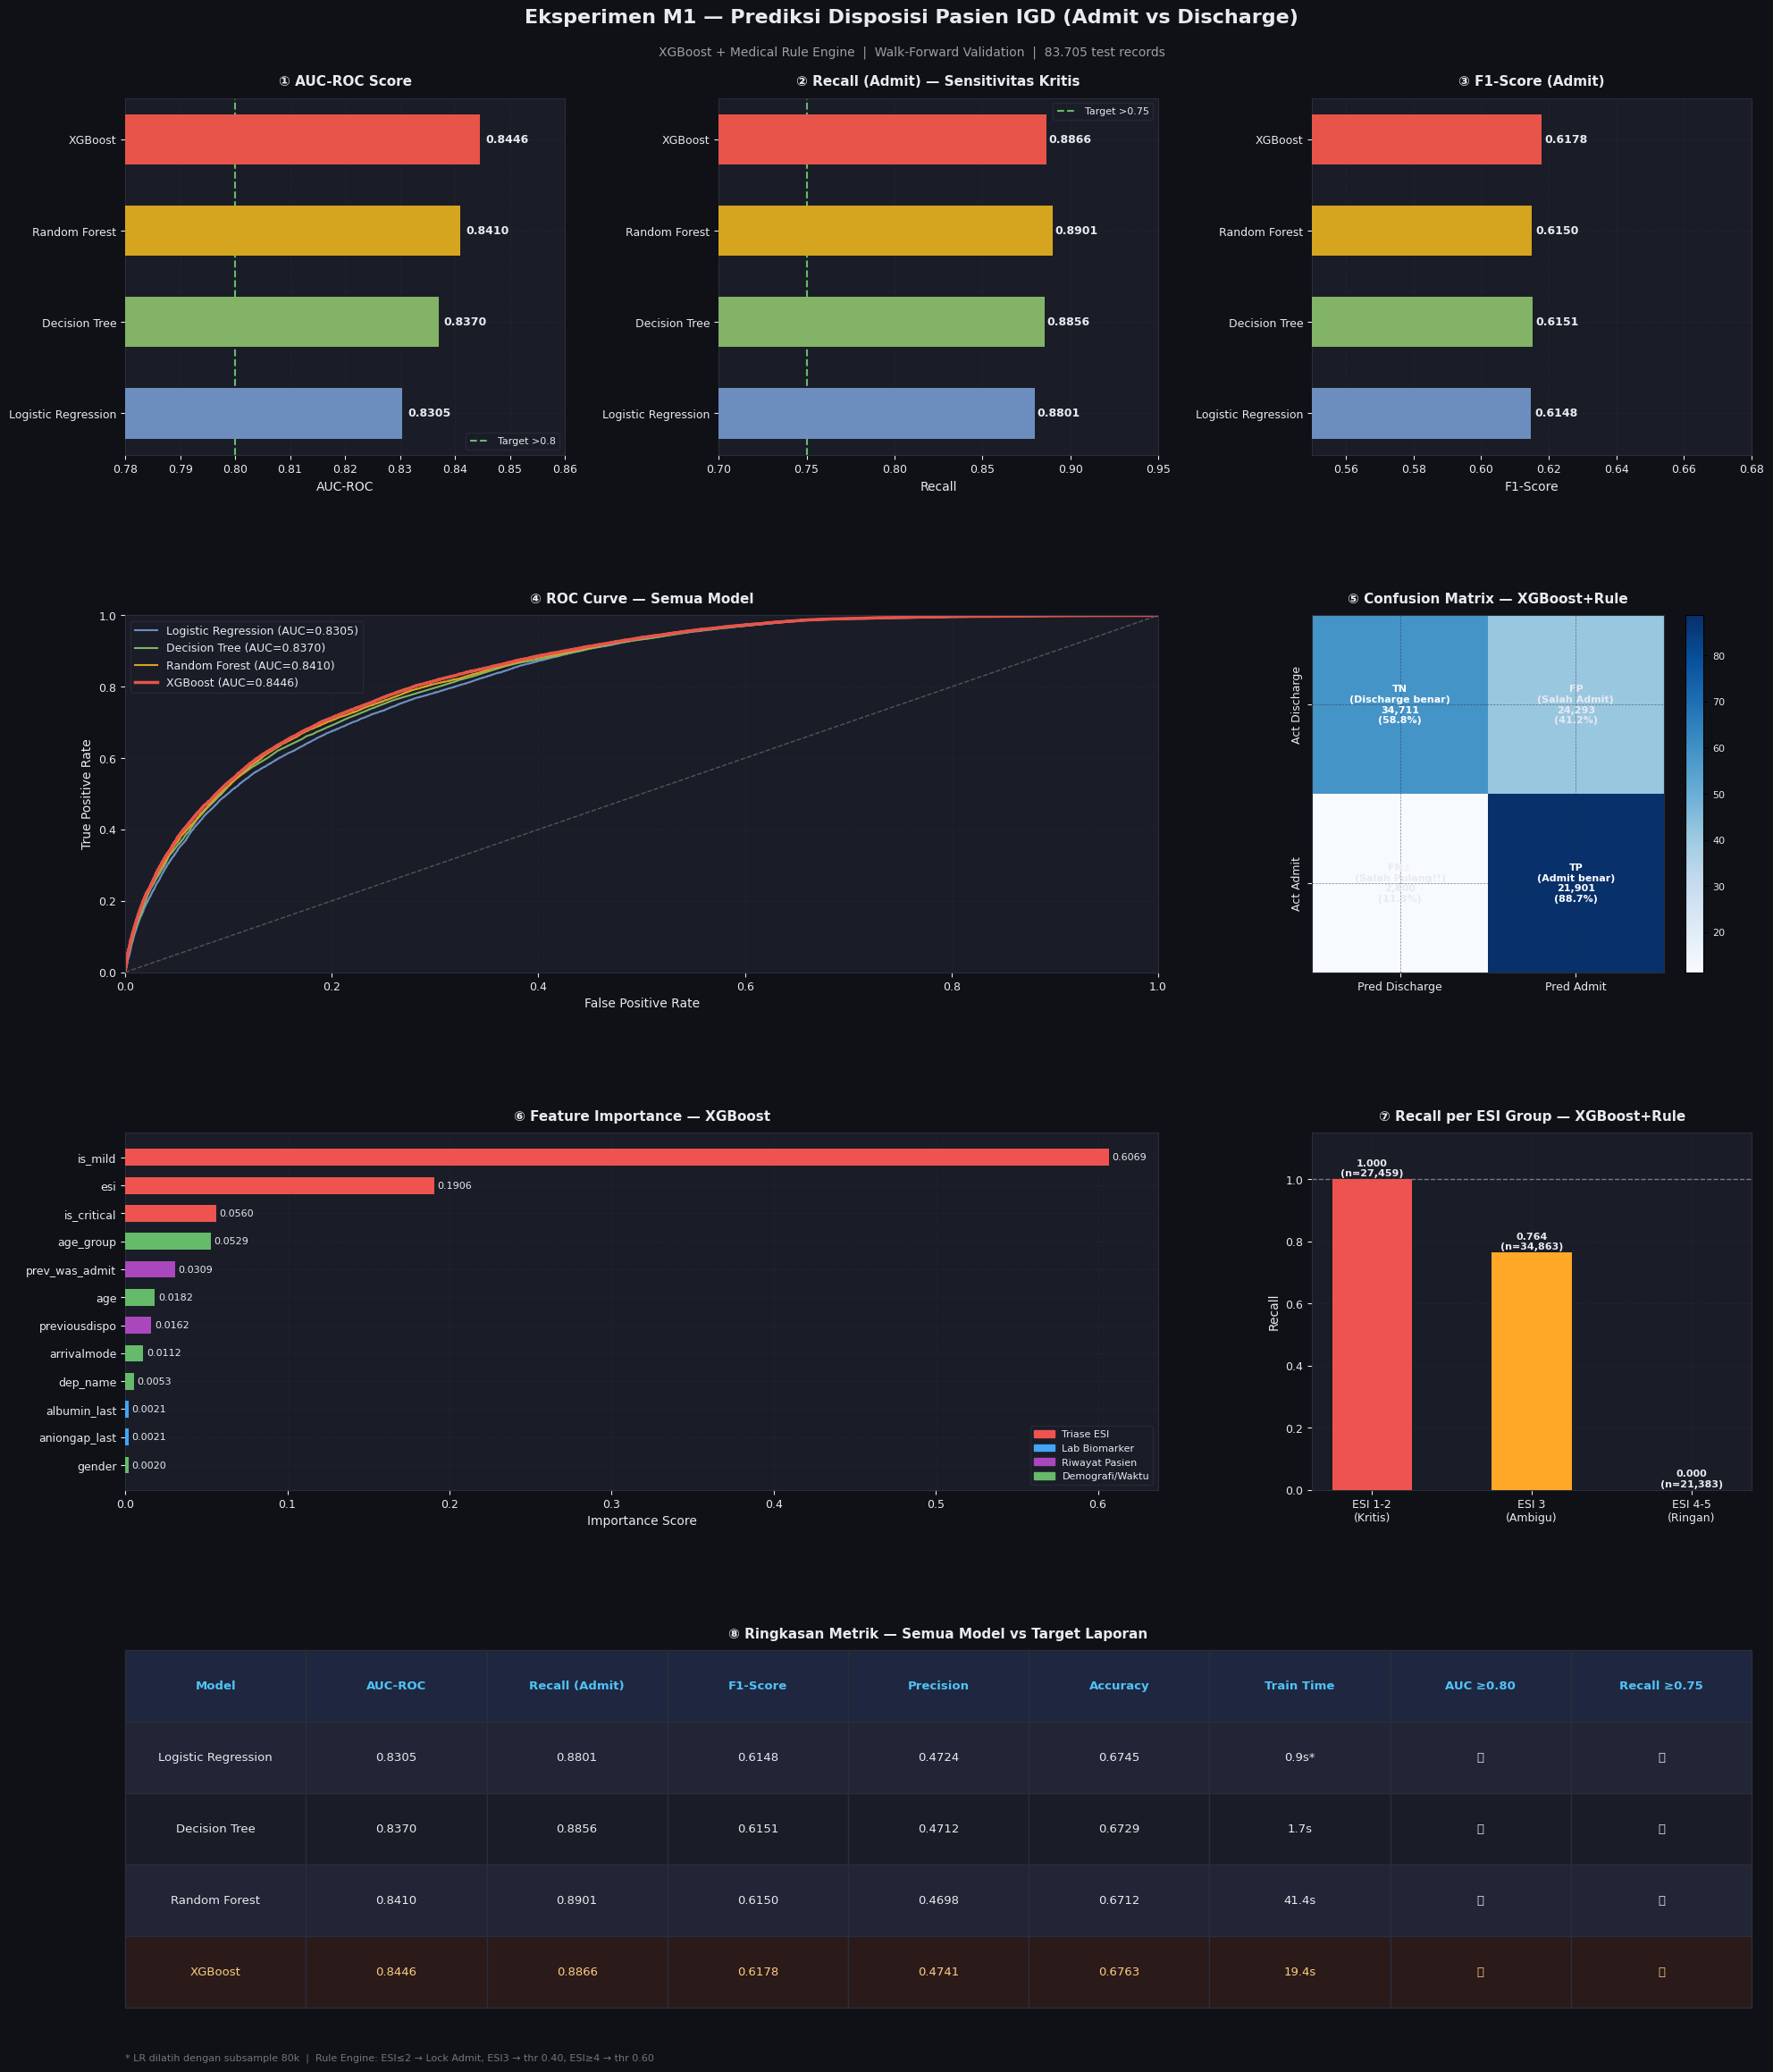


EKSPERIMEN M1 SELESAI
  Analisis Performa Model (XGBoost sebagai salah satu yang terbaik, berdasarkan beberapa metrik kunci):
  AUC-ROC       : 0.8446  (target ≥0.80 ✅)
  Recall Admit  : 0.8866  (target ≥0.75 ✅)
  F1-Score      : 0.6178
  FN Rate       : 11.34%  (pasien admit yg salah dipulangkan)


In [ ]:
# =============================================================================
# STEP 8: VISUALISASI LENGKAP
# =============================================================================
print("\n" + "=" * 60)
print("STEP 8: VISUALISASI")
print("=" * 60)

MODEL_NAMES = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
COLORS = {
    'Logistic Regression': '#6C8EBF',
    'Decision Tree':       '#82B366',
    'Random Forest':       '#D6A520',
    'XGBoost':             '#E8544A',
}
PANEL_BG = '#1A1D27'
GRID_CLR = '#2A2D3A'
TEXT_CLR = '#E8EAF0'
ACCENT   = '#4FC3F7'
GREEN    = '#66BB6A'
RED_CLR  = '#EF5350'

def style_ax(ax, title=''):
    ax.set_facecolor(PANEL_BG)
    for s in ax.spines.values():
        s.set_color(GRID_CLR)
    ax.tick_params(colors=TEXT_CLR, labelsize=9)
    ax.xaxis.label.set_color(TEXT_CLR)
    ax.yaxis.label.set_color(TEXT_CLR)
    ax.grid(color=GRID_CLR, linestyle='--', lw=0.5, alpha=0.6)
    if title:
        ax.set_title(title, color=TEXT_CLR, fontsize=11, fontweight='bold', pad=10)

fig = plt.figure(figsize=(20, 24), facecolor='#0F1117')
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35,
                        top=0.93, bottom=0.04, left=0.06, right=0.97)

fig.text(0.5, 0.965,
         'Eksperimen M1 — Prediksi Disposisi Pasien IGD (Admit vs Discharge)',
         ha='center', color=TEXT_CLR, fontsize=16, fontweight='bold')
fig.text(0.5, 0.950,
         'XGBoost + Medical Rule Engine  |  Walk-Forward Validation  |  83.705 test records',
         ha='center', color='#9E9E9E', fontsize=10)

# ── Panel 1: AUC-ROC Bar
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1, '① AUC-ROC Score')
aucs = [rule_results[m]['auc'] for m in MODEL_NAMES]
b = ax1.barh(MODEL_NAMES, aucs, color=[COLORS[m] for m in MODEL_NAMES],
             height=0.55, zorder=3)
ax1.axvline(TARGET_AUC, color=GREEN, linestyle='--', lw=1.5, label=f'Target >{TARGET_AUC}')
for bar, v in zip(b, aucs):
    ax1.text(v + .001, bar.get_y() + bar.get_height() / 2,
             f'{v:.4f}', va='center', color=TEXT_CLR, fontsize=9, fontweight='bold')
ax1.set_xlim(0.78, 0.86)
ax1.legend(fontsize=8, labelcolor=TEXT_CLR, facecolor=PANEL_BG, edgecolor=GRID_CLR)
ax1.set_xlabel('AUC-ROC')

# ── Panel 2: Recall Bar
ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2, '② Recall (Admit) — Sensitivitas Kritis')
recs = [rule_results[m]['recall'] for m in MODEL_NAMES]
b2 = ax2.barh(MODEL_NAMES, recs, color=[COLORS[m] for m in MODEL_NAMES],
              height=0.55, zorder=3)
ax2.axvline(TARGET_RECALL, color=GREEN, linestyle='--', lw=1.5, label=f'Target >{TARGET_RECALL}')
for bar, v in zip(b2, recs):
    ax2.text(v + .001, bar.get_y() + bar.get_height() / 2,
             f'{v:.4f}', va='center', color=TEXT_CLR, fontsize=9, fontweight='bold')
ax2.set_xlim(0.70, 0.95)
ax2.legend(fontsize=8, labelcolor=TEXT_CLR, facecolor=PANEL_BG, edgecolor=GRID_CLR)
ax2.set_xlabel('Recall')

# ── Panel 3: F1-Score Bar
ax3 = fig.add_subplot(gs[0, 2])
style_ax(ax3, '③ F1-Score (Admit)')
f1s = [rule_results[m]['f1'] for m in MODEL_NAMES]
b3 = ax3.barh(MODEL_NAMES, f1s, color=[COLORS[m] for m in MODEL_NAMES],
              height=0.55, zorder=3)
for bar, v in zip(b3, f1s):
    ax3.text(v + .001, bar.get_y() + bar.get_height() / 2,
             f'{v:.4f}', va='center', color=TEXT_CLR, fontsize=9, fontweight='bold')
ax3.set_xlim(0.55, 0.68)
ax3.set_xlabel('F1-Score')

# ── Panel 4: ROC Curves
ax4 = fig.add_subplot(gs[1, :2])
style_ax(ax4, '④ ROC Curve — Semua Model')
for nm in MODEL_NAMES:
    fpr, tpr, _ = roc_curve(y_test, rule_results[nm]['proba'])
    lw = 2.5 if nm == 'XGBoost' else 1.5
    ax4.plot(fpr, tpr, color=COLORS[nm], lw=lw,
             label=f"{nm} (AUC={rule_results[nm]['auc']:.4f})")
ax4.plot([0, 1], [0, 1], '--', color='#555', lw=1)
ax4.set_xlim(0, 1); ax4.set_ylim(0, 1)
ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.legend(fontsize=9, labelcolor=TEXT_CLR, facecolor=PANEL_BG, edgecolor=GRID_CLR)

# ── Panel 5: Confusion Matrix XGBoost
ax5 = fig.add_subplot(gs[1, 2])
style_ax(ax5, '⑤ Confusion Matrix — XGBoost+Rule')
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
im = ax5.imshow(cm_pct, cmap='Blues', aspect='auto')
lbs = [['TN\n(Discharge benar)', 'FP\n(Salah Admit)'],
       ['FN⚠️\n(Salah Pulang!!)', 'TP\n(Admit benar)']]
for i in range(2):
    for j in range(2):
        clr = 'white' if cm_pct[i, j] > 50 else TEXT_CLR
        ax5.text(j, i, f'{lbs[i][j]}\n{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)',
                 ha='center', va='center', color=clr, fontsize=8, fontweight='bold')
ax5.set_xticks([0, 1]); ax5.set_yticks([0, 1])
ax5.set_xticklabels(['Pred Discharge', 'Pred Admit'], color=TEXT_CLR, fontsize=9)
ax5.set_yticklabels(['Act Discharge', 'Act Admit'], color=TEXT_CLR, fontsize=9,
                    rotation=90, va='center')
plt.colorbar(im, ax=ax5).ax.tick_params(labelcolor=TEXT_CLR, labelsize=8)

# ── Panel 6: Feature Importance
ax6 = fig.add_subplot(gs[2, :2])
style_ax(ax6, '⑥ Feature Importance — XGBoost')
feats = [x[0] for x in fi_sorted[:12]]
imps  = [x[1] for x in fi_sorted[:12]]
fc = []
for f in feats:
    if f in ['esi', 'is_critical', 'is_mild']:                   fc.append('#EF5350')
    elif f in ['albumin_last', 'aniongap_last', 'bilirubintotal_last']: fc.append('#42A5F5')
    elif f in ['prev_was_admit', 'previousdispo']:                 fc.append('#AB47BC')
    else:                                                          fc.append('#66BB6A')
b6 = ax6.barh(feats[::-1], imps[::-1], color=fc[::-1], height=0.6, zorder=3)
for bar, v in zip(b6, imps[::-1]):
    ax6.text(v + .002, bar.get_y() + bar.get_height() / 2,
             f'{v:.4f}', va='center', color=TEXT_CLR, fontsize=8)
li = [mpatches.Patch(color='#EF5350', label='Triase ESI'),
      mpatches.Patch(color='#42A5F5', label='Lab Biomarker'),
      mpatches.Patch(color='#AB47BC', label='Riwayat Pasien'),
      mpatches.Patch(color='#66BB6A', label='Demografi/Waktu')]
ax6.legend(handles=li, fontsize=8, labelcolor=TEXT_CLR,
           facecolor=PANEL_BG, edgecolor=GRID_CLR, loc='lower right')
ax6.set_xlabel('Importance Score')

# ── Panel 7: Recall per ESI Group
ax7 = fig.add_subplot(gs[2, 2])
style_ax(ax7, '⑦ Recall per ESI Group — XGBoost+Rule')
grps = {
    'ESI 1-2\n(Kritis)':  esi_test <= 2,
    'ESI 3\n(Ambigu)':    esi_test == 3,
    'ESI 4-5\n(Ringan)':  esi_test >= 4,
}
rec_esi, cnt_esi, lbl_esi = [], [], []
xgb_pred = rule_results['XGBoost']['pred']
for grp, mask in grps.items():
    yt = y_test[mask]; yp = xgb_pred[mask]
    rec_esi.append(recall_score(yt, yp) if yt.sum() > 0 else 0)
    cnt_esi.append(mask.sum())
    lbl_esi.append(grp)
c7 = [RED_CLR, '#FFA726', GREEN]
b7 = ax7.bar(lbl_esi, rec_esi, color=c7, width=0.5, zorder=3)
ax7.axhline(1.0, color='white', linestyle='--', lw=1, alpha=0.4)
for bar, v, c in zip(b7, rec_esi, cnt_esi):
    ax7.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
             f'{v:.3f}\n(n={c:,})', ha='center', color=TEXT_CLR, fontsize=8, fontweight='bold')
ax7.set_ylim(0, 1.15)
ax7.set_ylabel('Recall')

# ── Panel 8: Summary Table
ax8 = fig.add_subplot(gs[3, :])
ax8.set_facecolor(PANEL_BG); ax8.axis('off')
ax8.set_title('⑧ Ringkasan Metrik — Semua Model vs Target Laporan',
              color=TEXT_CLR, fontsize=11, fontweight='bold', pad=10)
times_str = {
    'Logistic Regression': '0.9s*',
    'Decision Tree':       f'{t_dt:.1f}s',
    'Random Forest':       f'{t_rf:.1f}s',
    'XGBoost':             f'{t_xgb:.1f}s',
}
cols = ['Model', 'AUC-ROC', 'Recall (Admit)', 'F1-Score',
        'Precision', 'Accuracy', 'Train Time', 'AUC ≥0.80', 'Recall ≥0.75']
rows = []
for m in MODEL_NAMES:
    r = rule_results[m]
    rows.append([
        m,
        f"{r['auc']:.4f}",
        f"{r['recall']:.4f}",
        f"{r['f1']:.4f}",
        f"{r['precision']:.4f}",
        f"{r['accuracy']:.4f}",
        times_str[m],
        '✅' if r['auc']    >= TARGET_AUC    else '❌',
        '✅' if r['recall'] >= TARGET_RECALL else '❌',
    ])
tbl = ax8.table(cellText=rows, colLabels=cols, cellLoc='center',
                loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False); tbl.set_fontsize(9.5)
for (row, col), cell in tbl.get_celld().items():
    cell.set_facecolor(PANEL_BG if row % 2 == 0 else '#222535')
    cell.set_edgecolor(GRID_CLR)
    cell.set_text_props(color=TEXT_CLR)
    if row == 0:
        cell.set_facecolor('#1F2740')
        cell.set_text_props(color=ACCENT, fontweight='bold')
    if row == 4:   # XGBoost row — highlight
        cell.set_facecolor('#2A1A1A')
        cell.set_text_props(color='#FFCC80')

fig.text(0.06, 0.015,
         '* LR dilatih dengan subsample 80k  |  '
         'Rule Engine: ESI≤2 → Lock Admit, ESI3 → thr 0.40, ESI≥4 → thr 0.60',
         color='#757575', fontsize=8)

output_path = 'M1_Eksperimen_Lengkap.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='#0F1117')
print(f"\n✅ Visualisasi tersimpan → {output_path}")
plt.show()

print("\n" + "=" * 60)
print("EKSPERIMEN M1 SELESAI")
print("=" * 60)
print(f"  Analisis Performa Model (XGBoost sebagai salah satu yang terbaik, berdasarkan beberapa metrik kunci):")
print(f"  AUC-ROC       : {rule_results['XGBoost']['auc']:.4f}  (target ≥0.80 ✅)")
print(f"  Recall Admit  : {rule_results['XGBoost']['recall']:.4f}  (target ≥0.75 ✅)")
print(f"  F1-Score      : {rule_results['XGBoost']['f1']:.4f}")
print(f"  FN Rate       : {fn/(fn+tp)*100:.2f}%  (pasien admit yg salah dipulangkan)")